# 1. Introduction

This notebook builds a reproducible baseline multilayer perceptron (MLP) classifier for the UCI Adult Income dataset, predicting whether an individual's income is `<=50K` or `>50K` using demographic and employment-related features.

An MLP classifier is used because it is differentiable and supports the gradient-based fine-tuning and gradient-ascent methods evaluated later in this project. Tree-based models do not use gradient-updated neural-network weights, so they are not directly compatible with these particular gradient-based methods. This does not mean tree-based models cannot have other specialised unlearning approaches.

The baseline is deliberately conventional and has not undergone extensive hyperparameter optimisation. The objective is to build a stable comparison model for later unlearning experiments, not to obtain state-of-the-art Adult Income classification performance.

This baseline is the Original Model that later deletion and forgetting experiments will start from. Machine unlearning methods are not implemented here; they are developed in separate notebooks.


# 2. Imports and Setup

This helps to keep results reproducible 

In [1]:
from pathlib import Path
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


# Use one seed throughout the notebook for reproducibility.
RANDOM_SEED = 42
CLASSIFICATION_THRESHOLD = 0.5

HIDDEN_LAYER_DIMS = (64, 32)
DROPOUT_PROBABILITY = 0.2
BATCH_SIZE = 256
LEARNING_RATE = 0.001
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_MIN_DELTA = 1e-4

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Use Apple Silicon GPU through MPS on supported Macs.
# Fall back to CUDA if available, otherwise use CPU.
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
print(f"Classification threshold: {CLASSIFICATION_THRESHOLD}")


Using device: mps
Classification threshold: 0.5


# 3. Load Dataset

This loads the Adult Income dataset from the local project folder.

In [2]:
# Path is relative to this notebook: code/notebooks/adult/.
data_path = Path("../../data/raw/adult.csv")

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at: {data_path}")

df = pd.read_csv(data_path)

print(f"Loaded dataset from: {data_path}")
print(f"Dataset shape: {df.shape}")

Loaded dataset from: ../../data/raw/adult.csv
Dataset shape: (48842, 15)


# 4. Initial Data Inspection

Before any cleaning begins, the raw data is inspected, allowing some insight to inform a cleaning or preprocessing decision.

## 4.1 Dataset Information

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 48842
Columns: 15


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


## 4.2 Summary Statistics

In [5]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


## 4.3 Target Distribution

In [6]:
# Show both counts and percentages so class imbalance is easier to see.
target_distribution = pd.DataFrame(
    {
        "count": df["income"].value_counts(),
        "percentage": (df["income"].value_counts(normalize=True) * 100).round(2),
    }
)

target_distribution

,count,percentage
income,,
<=50K,37155,76.07
>50K,11687,23.93


## 4.4 Missing Values
The Adult dataset uses `?` as a missing-value placeholder in some categorical columns. These placeholders need to be identified before cleaning so they can be handled consistently.

In [7]:
# In the Adult dataset, missing categorical values are often stored as "?".
missing_placeholder_counts = (df == "?").sum().sort_values(ascending=False)
missing_placeholder_counts = missing_placeholder_counts[missing_placeholder_counts > 0]

missing_placeholder_counts

occupation        2809
workclass         2799
native-country     857
dtype: int64

## 4.5 Duplicate Records

Duplicate-looking rows are counted before cleaning. They should not be removed automatically because the dataset does not include a unique person identifier, so identical rows may still represent different individuals.

In [8]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 52


### Findings

The dataset has 48,842 rows and 15 columns with no true `NaN` values. Missing categorical values are instead represented as `?` placeholders, mainly in `occupation` and `workclass`.

The summary statistics show that `capital-gain` and `capital-loss` are heavily right-skewed, with many zero values and a small number of large positive values. Standardisation later places numerical columns on comparable scales for neural-network optimisation, but it does not remove this underlying skew.

The target is imbalanced at approximately 76% `<=50K` and 24% `>50K`. A classifier that always predicts `<=50K` would achieve approximately 76.07% accuracy. This illustrates why accuracy alone can be misleading for this imbalanced dataset and why F1-score and AUROC are also reported.

Only 52 duplicate-looking rows were found, around 0.1% of the data. These are kept because the dataset does not include a unique person identifier, so identical rows may still represent different individuals with the same recorded attributes.


# 5. Data Cleaning

The raw data should be cleaned and turned into a fully populated consistent dataset for cleaner unlearning. 

## 5.1 Create a Cleaning Copy

A copy of the raw dataframe is used so the original loaded data remains unchanged. This makes it easier to compare raw and cleaned values if needed.

In [9]:
# Work on a copy so the raw dataframe remains unchanged.
df_clean = df.copy()

print(f"Cleaning copy shape: {df_clean.shape}")

Cleaning copy shape: (48842, 15)


## 5.2 Strip Whitespace from Categorical Values

Whitespace in categorical values can create accidental duplicate categories, such as `Private` and ` Private`. Stripping whitespace ensures that equivalent categories are represented consistently.

In [10]:
# Only text columns need whitespace stripping.
categorical_columns = df_clean.select_dtypes(include=["object", "string"]).columns

for column in categorical_columns:
    df_clean[column] = df_clean[column].str.strip()

print("Whitespace stripped from categorical columns:")
print(list(categorical_columns))

Whitespace stripped from categorical columns:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


## 5.3 Replace Missing Placeholders

The Adult dataset represents some missing categorical values using `?`. These placeholders are replaced with `Unknown` so that missingness is preserved as an explicit category rather than dropping records.

In [11]:
# Keep missingness as an explicit category instead of dropping rows.
df_clean = df_clean.replace("?", "Unknown")

remaining_placeholders = (df_clean == "?").sum().sum()
print(f"Remaining '?' placeholders: {remaining_placeholders}")

Remaining '?' placeholders: 0


## 5.4 Verify Cleaning

After cleaning, the notebook checks for standard missing values, remaining `?` placeholders, and duplicate-looking rows. Duplicate rows are not removed as it is likely that these are different individuals who happen to share identical attributes, rather than true duplicates.

In [12]:
missing_values_after_cleaning = df_clean.isna().sum().sum()
duplicate_count_after_cleaning = df_clean.duplicated().sum()

print(f"Missing values after cleaning: {missing_values_after_cleaning}")
print(f"Duplicate rows after cleaning: {duplicate_count_after_cleaning}")
print(f"Cleaned dataset shape: {df_clean.shape}")

Missing values after cleaning: 0
Duplicate rows after cleaning: 52
Cleaned dataset shape: (48842, 15)


## 5.5 Save Cleaned Dataset

The cleaned dataset is saved so later notebooks can reuse the same cleaned data without repeating this step. Saving intermediate outputs improves reproducibility across the baseline and future unlearning experiments.

In [13]:
# Save the cleaned dataset in the processed data folder for reuse.
processed_dir = Path("../../data/processed/adult")
processed_dir.mkdir(parents=True, exist_ok=True)

cleaned_data_path = processed_dir / "adult_clean.csv"
df_clean.to_csv(cleaned_data_path, index=False)

print(f"Saved cleaned dataset to: {cleaned_data_path}")

Saved cleaned dataset to: ../../data/processed/adult/adult_clean.csv


# 6. Feature and Target Separation

The input features (`X`) are separated from the prediction target (`y`). The target is converted to a binary numerical label to be used by the PyTorch MLP.


## 6.1 Encode Target Variable

The original target values are text labels. They are encoded as `0` for `<=50K` and `1` for `>50K`, which is the format needed for binary classification.

In [14]:
# The original target is text, so map it to binary labels.
target_column = "income"

income_mapping = {
    "<=50K": 0,
    ">50K": 1,
}

df_clean["income_binary"] = df_clean[target_column].map(income_mapping)

if df_clean["income_binary"].isna().any():
    raise ValueError("Target encoding failed. Check for unexpected income labels.")

df_clean[[target_column, "income_binary"]].head()

,income,income_binary
0,<=50K,0
1,<=50K,0
2,>50K,1
3,>50K,1
4,<=50K,0


The mapping is written explicitly as a dictionary so that the 0/1 direction is unambiguous and documented in the code itself. 

## 6.2 Separate Features and Target

`X` contains only the model input features, while `y` contains the encoded target. Keeping these separate avoids accidentally using the target as an input feature.

In [15]:
# X contains model inputs; y contains only the prediction target.
X = df_clean.drop(columns=[target_column, "income_binary"])
y = df_clean["income_binary"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (48842, 14)
Target vector shape: (48842,)


Both income columns are dropped to prevent leakage.

## 6.3 Identify Feature Types

Numerical and categorical features are identified before splitting and preprocessing. Later, the scaler will be fitted only on numerical training features and the encoder only on categorical training features.

`fnlwgt` is a Census Bureau sampling weight reflecting population representation, not a property of the individual, and does not generalise as a predictive feature, so it is excluded from modelling.

`education` and `educational-num` represent the same underlying attribute. The ordinal `educational-num` feature is retained, while the redundant categorical `education` column is excluded before one-hot encoding.

In [16]:
# Feature lists are defined before splitting so the same schema is reused everywhere.
# These lists will be reused during preprocessing after the split.
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
# One-hot encoding uses categorical features only after removing redundant predictors.
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

# Exclude features that should not be used for modelling.
numerical_features = [feature for feature in numerical_features if feature != "fnlwgt"]
categorical_features = [feature for feature in categorical_features if feature != "education"]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical features:
['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


The feature-type lists are created here and reused later, so there is no risk of numerical and categorical columns being grouped differently during preprocessing.


# 7. Train / Validation / Test Split

The cleaned data is split into training, validation, and test sets. The training set is used to fit preprocessing and train the model, the validation set is used to monitor model performance during development, and the test set is kept untouched for final baseline evaluation.

## 7.1 Create 70 / 15 / 15 Split

The data is split using a 70/15/15 ratio with stratification, so there is enough data to train on while still keeping separate validation and test sets.

The split is stratified using the target variable so that each subset keeps a similar `<=50K` and `>50K` class balance. This is important because the Adult Income dataset is moderately imbalanced.

The split is done in two stages rather than one three-way split because `train_test_split` only supports splitting data into two parts at a time. The same `RANDOM_SEED` is used both times so the same indexed rows are selected after a clean rerun, which matters because later unlearning notebooks refer back to the same training and test records. `stratify=y` and `stratify=y_temp` are used so the validation and test sets also preserve similar class proportions.


In [17]:
# Stratification preserves the income-class balance across all splits.
# First split: 70% training and 30% temporary data.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y,
)

# Second split: split the temporary data equally into validation and test sets.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp,
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Training set: (34189, 14)
Validation set: (7326, 14)
Test set: (7327, 14)


## 7.2 Check Class Balance After Splitting

After splitting, the class distribution is checked again. This confirms that stratification preserved a similar target balance across training, validation, and test sets.

In [18]:
def show_class_distribution(split_name, labels):
    """Print target counts and percentages for one data split."""
    distribution = pd.DataFrame(
        {
            "count": labels.value_counts().sort_index(),
            "percentage": (labels.value_counts(normalize=True).sort_index() * 100).round(2),
        }
    )

    print(f"{split_name} class distribution")
    display(distribution)


show_class_distribution("Training", y_train)
show_class_distribution("Validation", y_val)
show_class_distribution("Test", y_test)

Training class distribution


,count,percentage
income_binary,,
0,26008,76.07
1,8181,23.93


Validation class distribution


,count,percentage
income_binary,,
0,5573,76.07
1,1753,23.93


Test class distribution


,count,percentage
income_binary,,
0,5574,76.07
1,1753,23.93


### Findings

The split produced 34,189 training rows, 7,326 validation rows, and 7,327 test rows, which together total 48,842. This confirms that no indexed records were lost between the splits.

All three sets show very similar class proportions: approximately 76.07% `<=50K` and 23.93% `>50K` in training and validation, and 76.06% / 23.94% in the test set. Stratification therefore preserved similar target proportions and reduced the risk of class imbalance distorting comparisons between the splits.


# 8. Feature Preprocessing

The cleaned features are converted into a numeric format, so that the data is in the shape a PyTorch MLP can actually accept as input.

## 8.1 Fit Preprocessing Objects on Training Data

Numerical features are standardised so they have comparable scales, which helps neural network optimisation. Categorical features are one-hot encoded so the MLP can use them as numeric inputs without assuming an artificial order between categories.

Fitting only on `X_train` is a deliberate data-leakage prevention step - if the scaler had seen validation or test rows when calculating its mean/variance, then information would have leaked into training. `OneHotEncoder(handle_unknown="ignore")` is used specifically so that if a category appears in validation/test that was never seen in training (most likely for the many rare `native-country` values), it's encoded as all-zeros instead of crashing the notebook.

In [19]:
# The scaler is fitted only on training rows to avoid validation/test leakage.
scaler = StandardScaler()
# Unknown categories are ignored so later notebooks can transform fixed splits safely.
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Fit preprocessing on training data only to avoid data leakage.
scaler.fit(X_train[numerical_features])
encoder.fit(X_train[categorical_features])

encoded_feature_names = encoder.get_feature_names_out(categorical_features).tolist()
processed_feature_names = numerical_features + encoded_feature_names

print(f"Number of processed features: {len(processed_feature_names)}")

Number of processed features: 91


## 8.2 Transform Train, Validation, and Test Sets

The fitted scaler and encoder are applied to each split. Validation and test data are transformed using training-fitted preprocessing objects so their information does not influence the fitted preprocessing.

In [20]:
def preprocess_features(features):
    """Scale numerical features and one-hot encode categorical features."""
    scaled_numerical = scaler.transform(features[numerical_features])
    encoded_categorical = encoder.transform(features[categorical_features])

    processed_array = np.concatenate(
        [scaled_numerical, encoded_categorical],
        axis=1,
    )

    return pd.DataFrame(
        processed_array,
        columns=processed_feature_names,
        index=features.index,
    )


X_train_processed = preprocess_features(X_train)
X_val_processed = preprocess_features(X_val)
X_test_processed = preprocess_features(X_test)

print(f"Processed training set: {X_train_processed.shape}")
print(f"Processed validation set: {X_val_processed.shape}")
print(f"Processed test set: {X_test_processed.shape}")

Processed training set: (34189, 91)
Processed validation set: (7326, 91)
Processed test set: (7327, 91)


## 8.3 Inspect Processed Features

A quick preview confirms that the preprocessing step produced a fully numeric feature matrix. These processed features will be converted to PyTorch tensors in the next section.

In [21]:
X_train_processed.head()

,age,educational-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Unknown,native-country_Vietnam,native-country_Yugoslavia
38865,-1.291271,-0.418928,-0.144333,-0.219417,1.569855,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
17212,-1.437112,-0.030135,-0.144333,-0.219417,-2.451436,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9312,-0.489145,-0.418928,-0.144333,-0.219417,0.363468,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
15512,-0.270383,1.136241,-0.144333,-0.219417,-0.038662,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
23576,-1.291271,0.747449,-0.144333,-0.219417,-0.440791,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### Findings

Preprocessing now uses 12 modelling columns after excluding `fnlwgt` and the redundant categorical `education` feature. This produced 91 numeric columns: the 5 retained numerical features stayed as single columns, while the 7 categorical features expanded into 86 one-hot columns. All three sets kept their original row counts (34,189 / 7,326 / 7,327), so no rows were lost.

The training numerical features are centred around zero after standardisation. Validation and test data use the training-fitted scaling statistics, so they are transformed consistently but are not guaranteed to have an exact mean of zero. The categorical columns are correctly shown as 0/1 flags, confirming that the data is fully numeric and ready to be converted into PyTorch tensors.


# 9. Convert to PyTorch Tensors

The processed pandas data is converted into PyTorch tensors. PyTorch models train on tensors rather than dataframes, so the feature matrices and target vectors need to be converted before creating dataloaders.

## 9.1 Convert Feature Matrices

The processed feature values are converted to `float32`, which is the standard numeric type used for neural network inputs in PyTorch.

In [22]:
X_train_tensor = torch.tensor(X_train_processed.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_processed.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed.values, dtype=torch.float32)

print(f"X_train_tensor: {X_train_tensor.shape}")
print(f"X_val_tensor: {X_val_tensor.shape}")
print(f"X_test_tensor: {X_test_tensor.shape}")

X_train_tensor: torch.Size([34189, 91])
X_val_tensor: torch.Size([7326, 91])
X_test_tensor: torch.Size([7327, 91])


## 9.2 Convert Target Vectors

The target labels are also converted to `float32`. They are reshaped to have one column because the MLP will output one logit per row for binary classification.

In [23]:
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print(f"y_train_tensor: {y_train_tensor.shape}")
print(f"y_val_tensor: {y_val_tensor.shape}")
print(f"y_test_tensor: {y_test_tensor.shape}")

y_train_tensor: torch.Size([34189, 1])
y_val_tensor: torch.Size([7326, 1])
y_test_tensor: torch.Size([7327, 1])


# 10. Create DataLoaders

The tensors are wrapped in PyTorch `TensorDataset` and `DataLoader` objects. DataLoaders make it simple to train the model in mini-batches instead of passing the full dataset through the network at once.

## 10.1 Create TensorDatasets

Each `TensorDataset` pairs feature tensors with their matching target tensors. This keeps each input row aligned with the correct income label.

In [24]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

print(f"Training batches will use {len(train_dataset)} records")
print(f"Validation dataset has {len(val_dataset)} records")
print(f"Test dataset has {len(test_dataset)} records")

Training batches will use 34189 records
Validation dataset has 7326 records
Test dataset has 7327 records


## 10.2 Create DataLoaders

The training loader is shuffled so the model sees mini-batches in a different order during training. A dedicated seeded `torch.Generator` is passed to the training `DataLoader` so batch shuffling is reproducible after a clean restart and rerun. Validation and test loaders are not shuffled because they are only used for evaluation.

This improves reproducibility, but it should not be read as a guarantee of bit-for-bit identical results across CPU, CUDA, and MPS devices, where low-level numerical behaviour can still differ slightly.


In [25]:
batch_size = BATCH_SIZE

training_generator = torch.Generator()
training_generator.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=training_generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

print(f"Batch size: {batch_size}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Batch size: 256
Training batches per epoch: 134
Validation batches: 29
Test batches: 29


### Findings

The datasets and loaders were built without losing any records: training, validation, and test datasets contain exactly 34,189, 7,326, and 7,327 records, matching the tensor shapes from Section 9. With a batch size of 256, this gives 134 training batches per epoch, and 29 batches each for validation and testing, confirming the data divides cleanly into batches close to the chosen batch size. This confirms the dataloaders are correctly set up and ready to be used in the training loop in the next section.

# 11. Define MLP

## 11.1 Define Model Class

The MLP takes the processed feature vector as input and outputs one logit for binary classification. `ReLU` activations introduce non-linearity, and dropout is included to reduce overfitting.

A small architecture is used (`input_dim -> 64 -> 32 -> 1`), where `input_dim` is derived automatically from the processed feature matrix. This keeps the same model design while allowing the input layer to match the corrected feature set. 

In [26]:
# The saved checkpoint metadata must match this architecture in later notebooks.
class AdultIncomeMLP(nn.Module):
    """Small baseline MLP for binary income classification."""

    def __init__(self, input_dim):
        super().__init__()

        hidden_dim_1, hidden_dim_2 = HIDDEN_LAYER_DIMS

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim_1),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT_PROBABILITY),
            nn.Linear(hidden_dim_1, hidden_dim_2),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT_PROBABILITY),
            nn.Linear(hidden_dim_2, 1),
        )

    def forward(self, features):
        return self.network(features)


## 11.2 Create Model, Loss Function, and Optimiser

`BCEWithLogitsLoss` is used because the model outputs a single raw logit for a binary target. Adam is used as a simple, reliable optimiser for this baseline.

In [27]:
input_dim = X_train_processed.shape[1]

# Move the model to the selected device: mps, cuda, or cpu.
model = AdultIncomeMLP(input_dim=input_dim).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)
print(f"Input dimension: {input_dim}")


AdultIncomeMLP(
  (network): Sequential(
    (0): Linear(in_features=91, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Input dimension: 91


# 12. Train Baseline Model

The baseline MLP is trained using the training set and monitors validation loss after each epoch. Early stopping is used to restore the best validation-loss checkpoint if validation loss stops improving, which helps reduce overfitting while keeping the training procedure reproducible.


## 12.1 Define Loss Calculation Helper

The helper function calculates the average loss for a full dataloader. It is used to evaluate validation loss without updating the model weights.

In [28]:
def calculate_average_loss(model, data_loader, criterion):
    """Calculate average loss over all batches in a dataloader."""
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)
            labels = labels.to(device)

            logits = model(features)
            loss = criterion(logits, labels)

            total_loss += loss.item() * features.size(0)

    return total_loss / len(data_loader.dataset)


## 12.2 Train the Model

The model is trained for up to a fixed maximum number of epochs, with early stopping.

In [29]:
# The training loop may stop early, but MAX_EPOCHS remains the configured upper bound.
num_epochs = MAX_EPOCHS
early_stopping_patience = EARLY_STOPPING_PATIENCE
early_stopping_min_delta = EARLY_STOPPING_MIN_DELTA

train_losses = []
val_losses = []
best_val_loss = float("inf")
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0
early_stopping_triggered = False

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for features, labels in train_loader:
        features = features.to(device)
        labels = labels.to(device)

        # Reset gradients from the previous batch.
        optimizer.zero_grad()

        # Forward pass, loss calculation, and weight update.
        logits = model(features)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * features.size(0)

    train_loss = running_train_loss / len(train_loader.dataset)
    val_loss = calculate_average_loss(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Validation loss must beat min_delta before the checkpoint is treated as better.
    improved = val_loss < (best_val_loss - early_stopping_min_delta)

    if improved:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        # Clone weights on CPU so later updates cannot mutate the saved best state.
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Validation loss: {val_loss:.4f} | "
        f"Best validation loss: {best_val_loss:.4f}"
    )

    if epochs_without_improvement >= early_stopping_patience:
        early_stopping_triggered = True
        print(
            "Early stopping triggered after "
            f"{epoch + 1} epochs. "
            f"Restoring epoch {best_epoch}."
        )
        break

# Training always ends by restoring the best validation checkpoint.
if best_model_state is not None:
    model.load_state_dict(
        {key: value.to(device) for key, value in best_model_state.items()}
    )

print(f"Best validation epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")


Epoch 01/20 | Train loss: 0.4238 | Validation loss: 0.3182 | Best validation loss: 0.3182
Epoch 02/20 | Train loss: 0.3239 | Validation loss: 0.3074 | Best validation loss: 0.3074
Epoch 03/20 | Train loss: 0.3166 | Validation loss: 0.3056 | Best validation loss: 0.3056
Epoch 04/20 | Train loss: 0.3133 | Validation loss: 0.3039 | Best validation loss: 0.3039
Epoch 05/20 | Train loss: 0.3111 | Validation loss: 0.3031 | Best validation loss: 0.3031
Epoch 06/20 | Train loss: 0.3099 | Validation loss: 0.3030 | Best validation loss: 0.3030
Epoch 07/20 | Train loss: 0.3085 | Validation loss: 0.3025 | Best validation loss: 0.3025
Epoch 08/20 | Train loss: 0.3073 | Validation loss: 0.3021 | Best validation loss: 0.3021
Epoch 09/20 | Train loss: 0.3073 | Validation loss: 0.3018 | Best validation loss: 0.3018
Epoch 10/20 | Train loss: 0.3053 | Validation loss: 0.3010 | Best validation loss: 0.3010
Epoch 11/20 | Train loss: 0.3050 | Validation loss: 0.3021 | Best validation loss: 0.3010
Epoch 12/2

## 12.3 Plot Training and Validation Loss

The loss curve gives a quick visual check of training progress. If early stopping triggers, the plotted curve shows only the epochs actually completed before the best validation checkpoint was restored.


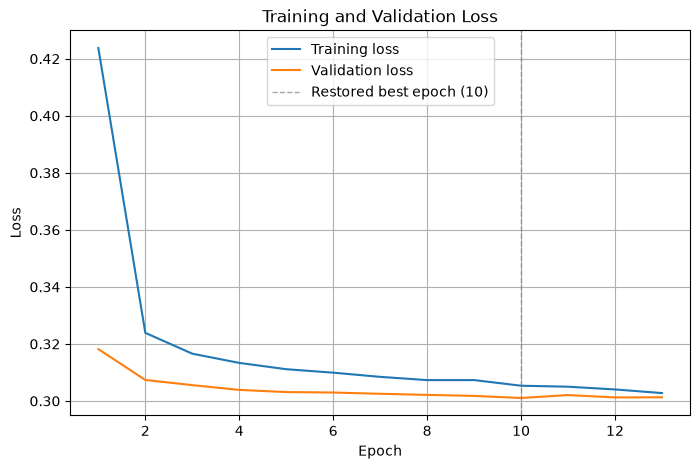

In [30]:
completed_epochs = range(1, len(train_losses) + 1)

loss_fig, loss_ax = plt.subplots(figsize=(8, 5))
loss_ax.plot(completed_epochs, train_losses, label="Training loss")
loss_ax.plot(completed_epochs, val_losses, label="Validation loss")
loss_ax.axvline(
    best_epoch,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label=f"Restored best epoch ({best_epoch})",
)
loss_ax.set_xlabel("Epoch")
loss_ax.set_ylabel("Loss")
loss_ax.set_title("Training and Validation Loss")
loss_ax.legend()
loss_ax.grid(True)
plt.show()


### 12.4 Findings

Training stopped early after epoch 13 and restored the epoch-10 checkpoint, where the best validation loss was 0.3010. This means the early-stopping logic did not keep the final epoch-13 weights; it rolled the model back to the best validation checkpoint found during training.

The loss curve shows the expected pattern: training loss continues to decrease gradually, while validation loss improves early and then begins to plateau. This confirms that the saved baseline uses the best validation-loss checkpoint rather than the last completed training epoch.


# 13. Evaluate Baseline Model

This section evaluates the trained baseline model on the untouched test set. The test set is used only after training so it provides a fair estimate of how well the baseline model generalises to unseen data.

## 13.1 Generate Test Predictions

The model outputs logits, which are converted to probabilities using the sigmoid function. The fixed classification threshold is then used to convert probabilities into binary class predictions.

The threshold is kept at 0.5 so the baseline and later unlearning methods can be compared consistently. It is not tuned using the test set.


In [31]:
model.eval()

test_probabilities = []
test_targets = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)

        logits = model(features)
        probabilities = torch.sigmoid(logits)

        test_probabilities.extend(probabilities.cpu().numpy().ravel())
        test_targets.extend(labels.numpy().ravel())

y_test_true = np.array(test_targets).astype(int)
y_test_prob = np.array(test_probabilities)
y_test_pred = (y_test_prob >= CLASSIFICATION_THRESHOLD).astype(int)

print(f"Generated predictions for {len(y_test_pred)} test records")


Generated predictions for 7327 test records


## 13.2 Calculate Evaluation Metrics

Accuracy gives the overall proportion of correct predictions. F1-score and AUROC are also included because the Adult Income target is moderately imbalanced.

In [32]:
baseline_metrics = {
    "accuracy": accuracy_score(y_test_true, y_test_pred),
    "f1_score": f1_score(y_test_true, y_test_pred),
    "roc_auc": roc_auc_score(y_test_true, y_test_prob),
}

baseline_metrics_df = pd.DataFrame(
    baseline_metrics.items(),
    columns=["metric", "value"],
)

baseline_metrics_df

,metric,value
0,accuracy,0.856012
1,f1_score,0.675085
2,roc_auc,0.909657


## 13.3 Classification Report and Confusion Matrix

The classification report shows precision, recall, and F1-score for each class. The confusion matrix shows the number of correct and incorrect predictions for both income groups.

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      5574
        >50K       0.73      0.63      0.68      1753

    accuracy                           0.86      7327
   macro avg       0.81      0.78      0.79      7327
weighted avg       0.85      0.86      0.85      7327

Confusion matrix:
[[5176  398]
 [ 657 1096]]


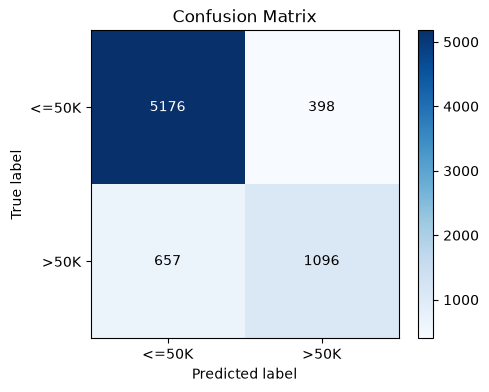

In [33]:
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=["<=50K", ">50K"],
))

conf_matrix = confusion_matrix(y_test_true, y_test_pred)
print("Confusion matrix:")
print(conf_matrix)

confusion_fig, confusion_ax = plt.subplots(figsize=(5, 4))
confusion_image = confusion_ax.imshow(conf_matrix, cmap="Blues")
confusion_ax.set_title("Confusion Matrix")
confusion_ax.set_xlabel("Predicted label")
confusion_ax.set_ylabel("True label")
confusion_ax.set_xticks([0, 1], ["<=50K", ">50K"])
confusion_ax.set_yticks([0, 1], ["<=50K", ">50K"])

annotation_threshold = conf_matrix.max() / 2

for row in range(conf_matrix.shape[0]):
    for column in range(conf_matrix.shape[1]):
        cell_value = conf_matrix[row, column]
        text_color = "white" if cell_value > annotation_threshold else "black"
        confusion_ax.text(
            column,
            row,
            cell_value,
            ha="center",
            va="center",
            color=text_color,
        )

confusion_fig.colorbar(confusion_image, ax=confusion_ax)
plt.show()


## 13.4 Plot ROC Curve

The ROC curve shows the trade-off between true positive rate and false positive rate across different probability thresholds. The AUROC summarises this curve into a single score.

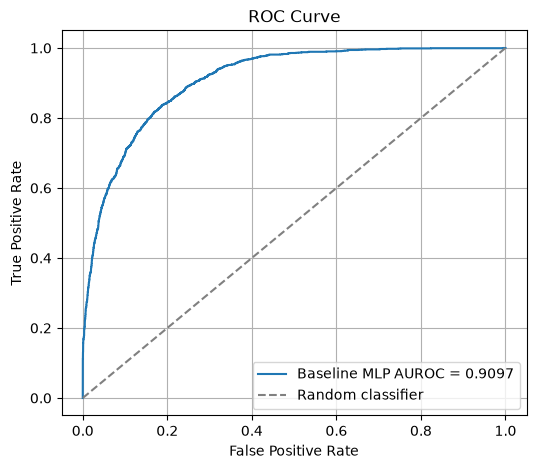

In [34]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_test_true,
    y_test_prob,
)

roc_fig, roc_ax = plt.subplots(figsize=(6, 5))
roc_ax.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Baseline MLP AUROC = {baseline_metrics['roc_auc']:.4f}",
)
roc_ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
roc_ax.set_xlabel("False Positive Rate")
roc_ax.set_ylabel("True Positive Rate")
roc_ax.set_title("ROC Curve")
roc_ax.legend()
roc_ax.grid(True)
plt.show()

### 13.5 Findings

The restored epoch-10 checkpoint achieves 85.60% test accuracy, an F1-score of 0.675, and an AUROC of 0.910. These values are from the corrected 91-feature baseline after excluding `fnlwgt` and the redundant categorical `education` column.

Against a trivial majority-class baseline of approximately 76.07% accuracy, from always predicting `<=50K`, the model provides a clear improvement. This confirms why the majority-class baseline is a useful reference point, while the F1-score and AUROC give additional information beyond accuracy.

The classification report and confusion matrix show a clear asymmetry between the two classes: recall on `<=50K` is high at 0.93, while recall on `>50K` is lower at 0.63. Out of 1,753 true `>50K` cases, 657 are missed and predicted as `<=50K`. This means the fixed 0.5 threshold makes the model more conservative about predicting the minority class, a common pattern on imbalanced datasets. Lowering the threshold would increase recall for `>50K` while generally reducing precision. Any future threshold selection should use validation data and then remain fixed across every method being compared.


# 14. Save Outputs

This section saves the cleaned data, fixed train/validation/test splits, preprocessing objects, trained model, metrics, and predictions. These saved files are needed so later machine unlearning notebooks can use the exact same baseline data and Original Model.


## 14.1 Create Output Directories

The project uses separate folders for processed data, trained models, and result tables. Creating the folders here makes the save step reproducible even if the folders do not already exist.

In [35]:
processed_adult_dir = Path("../../data/processed/adult")
models_adult_dir = Path("../../models/adult")
figures_dir = Path("../../results/figures")
metrics_dir = Path("../../results/metrics")
tables_dir = Path("../../results/tables")

for output_dir in [processed_adult_dir, models_adult_dir, figures_dir, metrics_dir, tables_dir]:
    output_dir.mkdir(parents=True, exist_ok=True)

print("Output directories ready.")

Output directories ready.


## 14.2 Save Data Splits

The raw cleaned splits and processed feature matrices are saved with their row indices preserved. Preserving indices is important for later unlearning notebooks because forget and retain sets must refer back to the same training records safely.

In [36]:
# Save unprocessed cleaned splits with indices preserved.
X_train.to_csv(processed_adult_dir / "X_train_raw.csv", index=True)
X_val.to_csv(processed_adult_dir / "X_val_raw.csv", index=True)
X_test.to_csv(processed_adult_dir / "X_test_raw.csv", index=True)

y_train.to_csv(processed_adult_dir / "y_train.csv", index=True)
y_val.to_csv(processed_adult_dir / "y_val.csv", index=True)
y_test.to_csv(processed_adult_dir / "y_test.csv", index=True)

# Save processed numeric feature matrices with indices preserved.
X_train_processed.to_csv(processed_adult_dir / "X_train_processed.csv", index=True)
X_val_processed.to_csv(processed_adult_dir / "X_val_processed.csv", index=True)
X_test_processed.to_csv(processed_adult_dir / "X_test_processed.csv", index=True)

print("Saved train/validation/test splits.")


Saved train/validation/test splits.


## 14.3 Save Preprocessing Objects and Feature Names

The fitted scaler and encoder are saved so future notebooks can apply the same preprocessing. The processed feature names are also saved to document the exact model input order.

For later unlearning experiments, note that the saved scaler and encoder were fitted using the original training set. A full end-to-end retraining benchmark after deletion would refit data-dependent preprocessing using only the retain set. If later experiments deliberately keep preprocessing fixed, that should be described as a model-only retraining comparison and acknowledged as a limitation.


In [37]:
joblib.dump(scaler, models_adult_dir / "adult_income_scaler.joblib")
joblib.dump(encoder, models_adult_dir / "adult_income_onehot_encoder.joblib")

feature_names_df = pd.DataFrame(
    {
        "processed_feature_name": processed_feature_names,
    }
)
feature_names_df.to_csv(tables_dir / "adult_processed_feature_names.csv", index=False)

print("Saved scaler, encoder, and processed feature names.")

Saved scaler, encoder, and processed feature names.


## 14.4 Save Trained Baseline Model

The PyTorch model is saved as the baseline Original Model. Later unlearning notebooks can load this file as the model trained before any deletion or unlearning request.

In [38]:
model_path = models_adult_dir / "adult_income_baseline_mlp.pt"

model_state_cpu = {
    key: value.detach().cpu().clone()
    for key, value in model.state_dict().items()
}

torch.save(
    {
        "model_state_dict": model_state_cpu,
        "input_dim": input_dim,
        "random_seed": RANDOM_SEED,
        "processed_feature_names": processed_feature_names,
        "numerical_features": numerical_features,
        "categorical_features": categorical_features,
        "classification_threshold": CLASSIFICATION_THRESHOLD,
        "hidden_layer_dims": HIDDEN_LAYER_DIMS,
        "dropout_probability": DROPOUT_PROBABILITY,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "early_stopping_triggered": early_stopping_triggered,
    },
    model_path,
)

print(f"Saved baseline model to: {model_path}")


Saved baseline model to: ../../models/adult/adult_income_baseline_mlp.pt


## 14.5 Save Figures

The plots shown in this notebook are also saved as PNG files. This makes it easier to reuse them later in dissertation notes, reports, or presentation slides.

In [39]:
loss_fig.savefig(figures_dir / "adult_baseline_mlp_loss_curve.png", dpi=300, bbox_inches="tight")
confusion_fig.savefig(figures_dir / "adult_baseline_mlp_confusion_matrix.png", dpi=300, bbox_inches="tight")
roc_fig.savefig(figures_dir / "adult_baseline_mlp_roc_curve.png", dpi=300, bbox_inches="tight")

print("Saved baseline figures.")

Saved baseline figures.


## 14.6 Save Metrics and Test Predictions

The final baseline metrics and test predictions are saved for reporting and later comparison with unlearning experiments. The test predictions include probabilities as well as thresholded class predictions.

In [40]:
baseline_metrics_df.to_csv(metrics_dir / "adult_baseline_mlp_metrics.csv", index=False)

test_predictions_df = pd.DataFrame(
    {
        "original_index": X_test_processed.index,
        "y_true": y_test_true,
        "y_probability": y_test_prob,
        "y_pred": y_test_pred,
    }
)
test_predictions_df.to_csv(tables_dir / "adult_baseline_mlp_test_predictions.csv", index=False)

print("Saved baseline metrics and test predictions.")

Saved baseline metrics and test predictions.


The baseline notebook is now complete. The saved model and data files define the starting point for later GDPR machine unlearning experiments.

The saved preprocessing objects were fitted on the original training set. Later notebooks should either keep that preprocessing fixed and describe the comparison as model-only, or explicitly refit preprocessing when making a full end-to-end retraining claim.
